<a href="https://colab.research.google.com/github/15003165-code/Proyecto/blob/main/Proyecto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final - Text Mining & Image Recognition
### Postgrado en Análisis y Predicción de Datos - Tercer Trimestre 2026

Este notebook contiene la solución completa de los dos ejercicios del proyecto final:

- **Problema 1:** Word Cloud sobre un dataset de tweets (menciones más citadas y su contexto).
- **Problema 2:** Fruits and Vegetables Recognizer con redes neuronales convolucionales (CNN).


# Problema 1 - Word Cloud
### Text Mining & Image Recognition - Proyecto Final

En este notebook vamos a trabajar con un dataset de aproximadamente 1.6 millones de tweets.

**Pasos que vamos a seguir:**
1. Cargar el dataset.
2. Usar expresiones regulares (regex) para encontrar las menciones `@usuario` dentro de los tweets.
3. Determinar los 3 usuarios más citados (más mencionados) en todo el dataset.
4. Armar un corpus por cada uno de esos 3 usuarios (Content, ID, Timestamp, Length).
5. Limpiar el texto, quitar stopwords, y aplicar stemming + lematización.
6. Analizar el contexto (palabras cercanas a la mención) para entender **por qué** se cita a cada usuario.
7. Mostrar un WordCloud con las 10 palabras de contexto más frecuentes por usuario.


In [1]:
# Instala las librerias necesarias en el Python que esta ejecutando este notebook.
%pip install wordcloud nltk --quiet


In [2]:
import pandas as pd                  # para manejar el dataset como tabla
import re                            # para expresiones regulares (regex)
import html                          # para "traducir" códigos HTML como &quot; a su símbolo real
from collections import Counter      # para contar palabras/menciones fácilmente

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [3]:
# Descargamos los recursos que necesita nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## Paso 1: Cargar el dataset

El archivo `tw_source.csv` no trae fila de encabezado, así que le ponemos nombres a las columnas
nosotros mismos: `target`, `id`, `timestamp`, `query`, `author`, `text`.

Usamos `encoding="latin-1"` porque el archivo no está guardado en UTF-8 (si se usa UTF-8 da error).


In [4]:
import os
import sys

# Detectamos si estamos en Google Colab
EN_COLAB = "google.colab" in sys.modules

DRIVE = "/content/drive/MyDrive"

# En Colab, siempre conectamos tu Google Drive y buscamos ahi los archivos
if EN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")


def buscar(nombre):

    if not EN_COLAB:
        if os.path.exists(nombre):
            return nombre
    else:
        ruta = os.path.join(DRIVE, nombre)
        if os.path.exists(ruta):
            return ruta
        for raiz, carpetas, archivos in os.walk(DRIVE):
            if nombre in archivos or nombre in carpetas:
                return os.path.join(raiz, nombre)

    raise FileNotFoundError(f"No encontre '{nombre}'. Guardalo en Mi unidad de Google Drive.")


Mounted at /content/drive


In [5]:
# Nombres de las columnas del dataset
columnas = ["target", "id", "timestamp", "query", "author", "text"]

# Leemos el csv
df = pd.read_csv(buscar("tw_source.csv"), header=None, names=columnas, encoding="latin-1")

print("Cantidad de tweets en el dataset:", len(df))
df.head()


Cantidad de tweets en el dataset: 1600000


,target,id,timestamp,query,author,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


## Paso 2: Encontrar los usuarios más citados con expresiones regulares

Un tweet "cita" o menciona a un usuario cuando escribe `@nombre_usuario` dentro del texto
(por ejemplo: `@mileycyrus i love you!!`).

Usamos una expresión regular para extraer todas las menciones de cada tweet y así contar
cuántas veces se menciona a cada usuario en todo el dataset.


In [6]:
# Esta expresión regular busca un @ seguido de letras/números/guion_bajo (\w+)
patron_mencion = re.compile(r"@(\w+)")

def extraer_menciones(texto):
    # findall regresa una lista con TODAS las menciones que encuentre en el texto
    return patron_mencion.findall(texto.lower())

# Aplicamos la función a cada tweet y vamos sumando todas las menciones encontradas
contador_menciones = Counter()
for lista_menciones in df["text"].apply(extraer_menciones):
    contador_menciones.update(lista_menciones)

# Tomamos los 3 usuarios con más menciones (los "más populares")
top_3 = contador_menciones.most_common(3)

print("Los 3 usuarios más citados son:")
for usuario, cantidad in top_3:
    print(f"  @{usuario}: {cantidad} menciones")

# Guardamos solo los nombres de usuario en una lista para usarlos más adelante
usuarios_top = [usuario for usuario, cantidad in top_3]
usuarios_top


Los 3 usuarios más citados son:
  @mileycyrus: 4580 menciones
  @tommcfly: 3904 menciones
  @ddlovato: 3474 menciones


['mileycyrus', 'tommcfly', 'ddlovato']

## Paso 3: Armar el corpus de cada usuario

Por cada uno de los 3 usuarios más citados, construimos un corpus (una tabla) con:
- **Content**: el texto del tweet.
- **ID**: identificador del tweet.
- **Timestamp**: fecha y hora del tweet.
- **Length**: cantidad de caracteres del tweet (este valor lo calculamos nosotros).

Cada corpus solo contiene los tweets que **mencionan** a ese usuario.


In [7]:
def tweet_menciona_usuario(texto, usuario):
    # \b significa "límite de palabra": evita que @tom haga match dentro de @tommcfly
    return re.search(rf"@{usuario}\b", texto, flags=re.IGNORECASE) is not None

corpus_por_usuario = {}

for usuario in usuarios_top:
    # Filtramos solo los tweets que mencionan a este usuario
    filtro = df["text"].apply(lambda texto: tweet_menciona_usuario(texto, usuario))
    subconjunto = df[filtro].copy()

    # Length = cantidad de caracteres del tweet
    subconjunto["Length"] = subconjunto["text"].str.len()

    # Nos quedamos solo con las columnas que pide el corpus, con los nombres pedidos
    corpus = subconjunto[["text", "id", "timestamp", "Length"]].rename(
        columns={"text": "Content", "id": "ID", "timestamp": "Timestamp"}
    ).reset_index(drop=True)

    corpus_por_usuario[usuario] = corpus
    print(f"Corpus de @{usuario}: {len(corpus)} tweets")


Corpus de @mileycyrus: 4562 tweets
Corpus de @tommcfly: 3898 tweets
Corpus de @ddlovato: 3460 tweets


In [8]:
# Vista rápida del corpus del primer usuario del top 3
corpus_por_usuario[usuarios_top[0]].head()


,Content,ID,Timestamp,Length
0,@mileycyrus hahaha dont be like that one time ...,1468063101,Mon Apr 06 23:30:57 PDT 2009,107
1,"@mileycyrus i have the same problem, but it's ...",1468286517,Tue Apr 07 00:45:20 PDT 2009,137
2,@mileycyrus I guess counting sheep didn't work...,1468297110,Tue Apr 07 00:49:07 PDT 2009,72
3,@mileycyrus I would too if it meant spending a...,1468298918,Tue Apr 07 00:49:44 PDT 2009,100
4,@mileycyrus AWWW u seriously have the cutest d...,1468318249,Tue Apr 07 00:56:41 PDT 2009,112


## Paso 4: Limpiar el texto y extraer el contexto de cada mención

Para entender **por qué** se cita a un usuario, revisamos qué palabras aparecen cerca de la
mención: las 5 palabras antes y las 5 palabras después.

Antes de contar las palabras, limpiamos el texto siguiendo estos pasos:

1. Convertir códigos HTML como `&quot;` a su símbolo real (`"`). Esto es necesario porque el
   dataset trae estos códigos sin traducir y si no los limpiamos aparecen como palabras falsas
   (por ejemplo "quot").
2. Pasar todo a minúsculas.
3. Quitar links (http...).
4. Quitar números y signos de puntuación.
5. Quitar "stopwords" (palabras muy comunes sin significado propio: the, and, is, etc.).
6. Aplicar **lematización** (llevar la palabra a su forma base, ej. "loving" -> "love").
7. Aplicar **stemming** (recortar la palabra a su raíz, ej. "loving" -> "lov").


In [9]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lematizador = WordNetLemmatizer()

def limpiar_texto(texto):
    texto = html.unescape(texto)                     # &quot; -> "
    texto = texto.lower()                             # todo a minúsculas
    texto = re.sub(r"http\S+|www\S+", "", texto)     # quitar links
    texto = re.sub(r"[^a-z@\s]", " ", texto)          # dejar solo letras, @ y espacios
    return texto

def obtener_contexto(texto, usuario, ventana=5):
    texto_limpio = limpiar_texto(texto)
    palabras = texto_limpio.split()
    mencion = f"@{usuario}"

    # Si por algún motivo la mención ya no aparece después de limpiar, no hay contexto
    if mencion not in palabras:
        return []

    posicion = palabras.index(mencion)
    inicio = max(0, posicion - ventana)
    fin = posicion + ventana + 1

    # Palabras antes y después de la mención (sin incluir la mención misma)
    contexto = palabras[inicio:posicion] + palabras[posicion + 1:fin]

    # Quitamos stopwords, palabras muy cortas (1-2 letras) y otras menciones
    contexto = [p for p in contexto if p not in stop_words and len(p) > 2 and not p.startswith("@")]

    # Primero lematizamos y después aplicamos stemming
    contexto = [lematizador.lemmatize(p) for p in contexto]
    contexto = [stemmer.stem(p) for p in contexto]

    return contexto


## Paso 5: Top 10 palabras de contexto por usuario
todos los tweets del corpus de cada usuario, juntamos las palabras de
contexto de todos ellos, y contamos cuáles son las 10 más frecuentes.


In [10]:
top_palabras_por_usuario = {}

for usuario in usuarios_top:
    todas_las_palabras = []
    for texto in corpus_por_usuario[usuario]["Content"]:
        todas_las_palabras.extend(obtener_contexto(texto, usuario))

    contador = Counter(todas_las_palabras)
    top_10 = dict(contador.most_common(10))
    top_palabras_por_usuario[usuario] = top_10

    print(f"Top 10 palabras de contexto para @{usuario}:")
    for palabra, cantidad in top_10.items():
        print(f"  {palabra}: {cantidad}")
    print()


Top 10 palabras de contexto para @mileycyrus:
  miley: 588
  love: 363
  vote: 267
  hey: 175
  good: 172
  come: 164
  hope: 157
  pleas: 112
  luck: 104
  best: 98

Top 10 palabras de contexto para @tommcfly:
  tom: 562
  say: 174
  hey: 154
  pleas: 148
  love: 144
  good: 137
  come: 117
  like: 103
  haha: 97
  miss: 95

Top 10 palabras de contexto para @ddlovato:
  demi: 420
  love: 252
  wish: 164
  hey: 119
  come: 115
  hope: 105
  pleas: 103
  wait: 92
  awesom: 90
  could: 87



## Paso 6: WordCloud por usuario

Por último, mostramos un WordCloud (nube de palabras) por cada usuario, usando las
10 palabras de contexto más frecuentes que calculamos en el paso anterior.


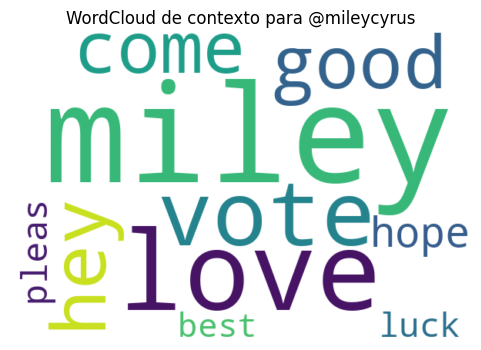

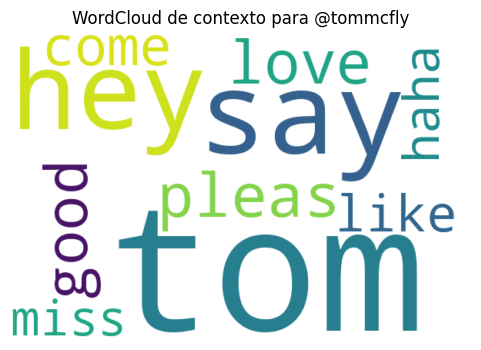

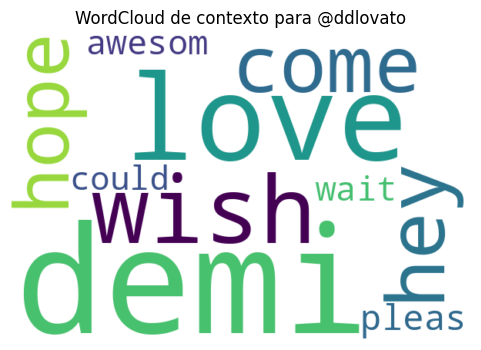

In [11]:
for usuario in usuarios_top:
    frecuencias = top_palabras_por_usuario[usuario]

    wc = WordCloud(width=600, height=400, background_color="white").generate_from_frequencies(frecuencias)

    plt.figure(figsize=(6, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud de contexto para @{usuario}")
    plt.show()


## Conclusión: ¿por qué se cita a cada usuario?

Con base en las palabras de contexto obtenidas para el top 3 (`@mileycyrus`, `@tommcfly`,
`@ddlovato`), podemos observar lo siguiente:

- **@mileycyrus**: palabras como *miley, love, vote, hope, luck, best* muestran que la mayoría
  de las menciones son de fans expresando cariño, pidiendo votos (posiblemente para algún
  premio o concurso) y deseándole suerte.
- **@tommcfly**: palabras como *tom, say, please, love, miss* sugieren mensajes de fans
  pidiéndole atención/respuesta y expresando que lo extrañan.
- **@ddlovato**: palabras como *demi, love, wish, hope, please, awesome* indican mensajes de
  fans expresando admiración y esperando alguna respuesta de ella.

En los tres casos el patrón es similar: son **celebridades (cantantes/actrices)** mencionadas
principalmente por sus **fans**, con mensajes de cariño, apoyo y peticiones de respuesta,
algo típico de Twitter en el año en que se recolectó este dataset (2009).


---
---
# Problema 2: Fruits and Vegetables Recognizer
---
---


# Problema 2 - Fruits and Vegetables Recognizer
### Text Mining & Image Recognition - Proyecto Final

En este notebook vamos a construir un clasificador de imágenes con redes neuronales
convolucionales (CNN) capaz de distinguir entre distintos tipos de frutas y verduras.

**Decisiones de diseño tomadas para este proyecto:**
- **Frutas elegidas:** Apple (manzana), Banana, Mango.
- **Verduras elegidas:** Carrot (zanahoria), Potato (papa), Tomato (tomate).
- El dataset original divide cada fruta/verdura en "Fresh" y "Rotten" (fresca/podrida). Como el
  objetivo es distinguir **tipos** de frutas/verduras (no su estado), unimos ambas carpetas en
  una sola clase por tipo (ej. `FreshApple` + `RottenApple` -> clase `Apple`).
- **Color:** usamos imágenes a color (RGB), ya que el color es una señal muy importante para
  diferenciar frutas y verduras (ej. tomate rojo vs papa marrón).
- **Tamaño de imagen:** redimensionamos todo a 64x64 píxeles, para que el entrenamiento sea
  razonablemente rápido incluso sin GPU.
- **División de datos:** 70% entrenamiento, 15% validación, 15% prueba.

**Pasos que vamos a seguir:**
1. Organizar el dataset en carpetas `train` / `val` / `test` por clase.
2. Aplicar Data Augmentation y normalizar las imágenes con `ImageDataGenerator` y `flow_from_directory`.
3. Diseñar y entrenar 3 arquitecturas de CNN distintas.
4. Comparar cuál de las 3 funciona mejor y explicar por qué.


In [12]:
import os                # para recorrer carpetas y archivos
import shutil             # para copiar archivos
import zipfile            # para descomprimir el zip del dataset
import random              # para mezclar y dividir los datos de forma aleatoria

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Fijamos una "semilla" para que los resultados sean reproducibles
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


## Paso 1: Organizar el dataset en train / val / test

Descargamos el dataset de frutas y verduras desde Kaggle (link en el enunciado) y lo
descomprimimos. Debe quedar una carpeta `Fruits_Vegetables_Dataset(12000)` con dos subcarpetas:
`Fruits/` y `Vegetables/`, y dentro de cada una, una carpeta por cada combinación
fruta/verdura + estado (ej. `FreshApple`, `RottenApple`, etc.).

Como explicamos arriba, elegimos 3 frutas y 3 verduras, y **unimos** las versiones Fresh y
Rotten de cada una en una sola clase (porque queremos reconocer el *tipo* de fruta/verdura,
no si está fresca o podrida).

El siguiente código arma una nueva carpeta `dataset_split/` con la estructura:

```
dataset_split/
    train/
        Apple/ ...
        Banana/ ...
        ...
    val/
        Apple/ ...
        ...
    test/
        Apple/ ...
        ...
```


In [13]:
# Carpeta donde esta el dataset original de frutas y verduras
base = "Fruits_Vegetables_Dataset(12000)"

# Si la carpeta no esta junto al notebook, la buscamos (por ejemplo en Mi unidad de Drive).
# Si solo existe el .zip, lo descomprimimos.
if not os.path.isdir(base):
    try:
        base = buscar(base)
    except FileNotFoundError:
        print("Descomprimiendo el dataset de frutas, esto puede tardar un par de minutos...")
        with zipfile.ZipFile(buscar(base + ".zip"), "r") as zip_ref:
            zip_ref.extractall(".")
        print("Listo.")

# Carpeta donde vamos a crear la nueva estructura train/val/test
salida = "dataset_split"

# Por cada clase que elegimos, indicamos de qué carpetas originales sacar las imágenes
# (unimos Fresh + Rotten de cada fruta/verdura en una sola clase)
clases = {
    "Apple":  [os.path.join(base, "Fruits", "FreshApple"),  os.path.join(base, "Fruits", "RottenApple")],
    "Banana": [os.path.join(base, "Fruits", "FreshBanana"), os.path.join(base, "Fruits", "RottenBanana")],
    "Mango":  [os.path.join(base, "Fruits", "FreshMango"),  os.path.join(base, "Fruits", "RottenMango")],
    "Carrot": [os.path.join(base, "Vegetables", "FreshCarrot"), os.path.join(base, "Vegetables", "RottenCarrot")],
    "Potato": [os.path.join(base, "Vegetables", "FreshPotato"), os.path.join(base, "Vegetables", "RottenPotato")],
    "Tomato": [os.path.join(base, "Vegetables", "FreshTomato"), os.path.join(base, "Vegetables", "RottenTomato")],
}

# Porcentajes de la división
proporciones = {"train": 0.70, "val": 0.15, "test": 0.15}

# Si ya existe una version anterior de la carpeta de salida, la borramos para empezar limpio
if os.path.exists(salida):
    shutil.rmtree(salida, ignore_errors=True)

resumen = {}
for clase, carpetas_origen in clases.items():
    # Juntamos las rutas de todas las imagenes (fresh + rotten) de esta clase
    archivos = []
    for carpeta in carpetas_origen:
        for nombre_archivo in os.listdir(carpeta):
            archivos.append(os.path.join(carpeta, nombre_archivo))

    # Mezclamos aleatoriamente antes de dividir
    random.shuffle(archivos)

    n = len(archivos)
    n_train = int(n * proporciones["train"])
    n_val = int(n * proporciones["val"])

    partes = {
        "train": archivos[:n_train],
        "val": archivos[n_train:n_train + n_val],
        "test": archivos[n_train + n_val:],
    }

    resumen[clase] = {}
    for nombre_parte, lista_archivos in partes.items():
        carpeta_destino = os.path.join(salida, nombre_parte, clase)
        os.makedirs(carpeta_destino, exist_ok=True)
        for ruta_origen in lista_archivos:
            shutil.copy2(ruta_origen, carpeta_destino)
        resumen[clase][nombre_parte] = len(lista_archivos)

# Mostramos un resumen de cuantas imagenes quedaron en cada division
print(f"{'Clase':<10} {'train':>8} {'val':>8} {'test':>8}")
for clase, r in resumen.items():
    print(f"{clase:<10} {r['train']:>8} {r['val']:>8} {r['test']:>8}")


Clase         train      val     test
Apple           840      180      180
Banana          840      180      180
Mango           838      179      181
Carrot          840      180      180
Potato          840      180      180
Tomato          840      180      180


## Paso 2: Data Augmentation y Preprocesamiento

Usamos `ImageDataGenerator` de Keras para:
- **Normalizar** los píxeles de las imágenes a valores entre 0 y 1 (`rescale=1./255`).
- **Aumentar los datos de entrenamiento** aplicando pequeñas transformaciones aleatorias:
  rotación, zoom (escalado) y flip horizontal. Esto ayuda a que el modelo sea más robusto ante
  variaciones de tamaño, rotación e iluminación, tal como pide el enunciado.
- Redimensionar todas las imágenes a **64x64 píxeles** (`target_size`) al momento de cargarlas
  con `flow_from_directory`.

**Importante:** a los datos de validación y prueba **no** les aplicamos data augmentation
(solo normalizamos), porque queremos evaluar el modelo con imágenes "reales", no modificadas.


In [14]:
# Generador para ENTRENAMIENTO: normaliza y aplica data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,        # normaliza los pixeles a valores entre 0 y 1
    rotation_range=30,     # rota la imagen aleatoriamente hasta 30 grados
    zoom_range=0.2,        # aplica un zoom (escalado) aleatorio de hasta 20%
    horizontal_flip=True,  # voltea la imagen horizontalmente al azar
)

# Generador para VALIDACION y PRUEBA: solo normaliza, sin augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

TAMANO_IMAGEN = (64, 64)
BATCH_SIZE = 32

train_gen = train_datagen.flow_from_directory(
    "dataset_split/train",
    target_size=TAMANO_IMAGEN,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    seed=42,
)

val_gen = val_test_datagen.flow_from_directory(
    "dataset_split/val",
    target_size=TAMANO_IMAGEN,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    seed=42,
)

test_gen = val_test_datagen.flow_from_directory(
    "dataset_split/test",
    target_size=TAMANO_IMAGEN,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    seed=42,
    shuffle=False,   # no mezclamos el test, para poder comparar predicciones despues
)

print("Clases y su indice numerico:", train_gen.class_indices)


Found 5028 images belonging to 6 classes.
Found 1077 images belonging to 6 classes.
Found 1079 images belonging to 6 classes.
Clases y su indice numerico: {'Apple': 0, 'Banana': 1, 'Carrot': 2, 'Mango': 3, 'Potato': 4, 'Tomato': 5}


### Vista previa de las imágenes aumentadas

Antes de entrenar, veamos cómo se ven algunas imágenes después de aplicarles data augmentation,
solo para confirmar visualmente que la rotación, el zoom y el flip se están aplicando bien.


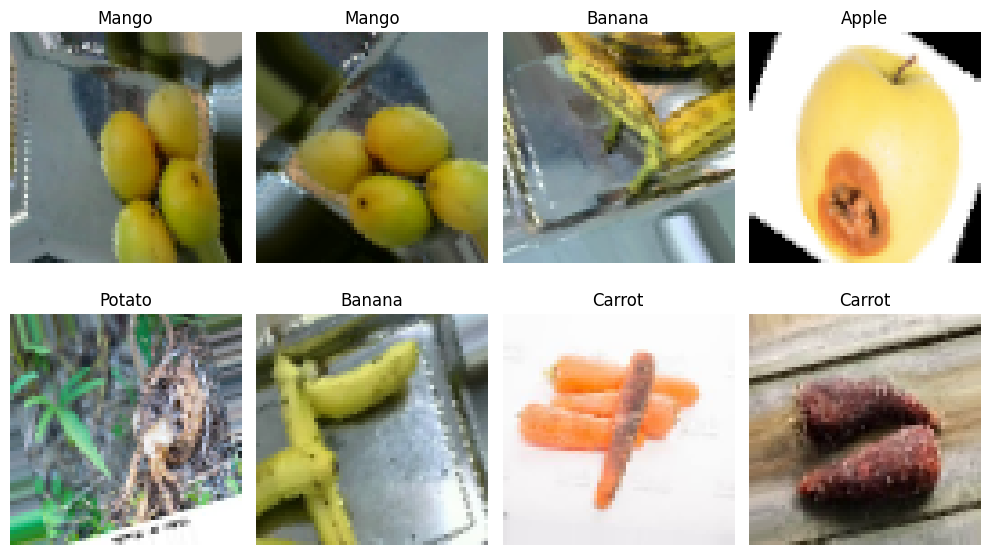

In [15]:
# Tomamos un batch (lote) de imagenes ya aumentadas y normalizadas
imagenes_lote, etiquetas_lote = next(train_gen)

# Diccionario para pasar de indice numerico a nombre de clase
indice_a_clase = {v: k for k, v in train_gen.class_indices.items()}

plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(imagenes_lote[i])
    clase_idx = np.argmax(etiquetas_lote[i])
    plt.title(indice_a_clase[clase_idx])
    plt.axis("off")
plt.tight_layout()
plt.show()


## Paso 3: Diseño de 3 arquitecturas de CNN

Vamos a probar 3 arquitecturas distintas, de menor a mayor complejidad:

1. **Arquitectura 1 (Simple):** 2 bloques de Convolución + MaxPooling. Rápida de entrenar,
   pero con menor capacidad para aprender patrones complejos.
2. **Arquitectura 2 (Intermedia):** 3 bloques de Convolución + MaxPooling, más un `Dropout`
   antes de la capa de salida para reducir el sobreajuste (overfitting).
3. **Arquitectura 3 (Profunda):** 4 bloques de Convolución + `BatchNormalization` + MaxPooling,
   más `Dropout`. Es la más compleja y profunda de las tres.

En las 3 usamos:
- Capas `Conv2D` con activación `relu` para extraer características (bordes, texturas, formas).
- `MaxPooling2D` para reducir el tamaño de la imagen y quedarnos con la información más
  importante (esto también hace la red más rápida y más robusta a pequeños desplazamientos).
- Una capa `Dense` final con activación `softmax` y 6 neuronas (una por clase), ya que es un
  problema de clasificación multi-clase.


In [16]:
def arquitectura_1_simple():
    modelo = models.Sequential([
        layers.Input(shape=(64, 64, 3)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(6, activation="softmax"),
    ], name="Arquitectura_1_Simple")
    modelo.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return modelo


def arquitectura_2_intermedia():
    modelo = models.Sequential([
        layers.Input(shape=(64, 64, 3)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(6, activation="softmax"),
    ], name="Arquitectura_2_Intermedia")
    modelo.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return modelo


def arquitectura_3_profunda():
    modelo = models.Sequential([
        layers.Input(shape=(64, 64, 3)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(6, activation="softmax"),
    ], name="Arquitectura_3_Profunda")
    modelo.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return modelo


arquitecturas = {
    "Arquitectura 1 (Simple)": arquitectura_1_simple,
    "Arquitectura 2 (Intermedia)": arquitectura_2_intermedia,
    "Arquitectura 3 (Profunda)": arquitectura_3_profunda,
}

# Vemos un resumen rapido de cada arquitectura antes de entrenar
for nombre, constructor in arquitecturas.items():
    modelo_temp = constructor()
    print(f"=== {nombre} ===")
    print("Parametros entrenables:", modelo_temp.count_params())
    print()


=== Arquitectura 1 (Simple) ===
Parametros entrenables: 822662

=== Arquitectura 2 (Intermedia) ===
Parametros entrenables: 683974

=== Arquitectura 3 (Profunda) ===
Parametros entrenables: 375110



## Paso 4: Entrenamiento y comparación de las 3 arquitecturas

Entrenamos cada arquitectura con los mismos datos (`train_gen`) y la misma cantidad de épocas,
y medimos su desempeño en el conjunto de **validación** (`val_gen`) para poder compararlas de
forma justa. Al final, evaluamos a las 3 en el conjunto de **prueba** (`test_gen`), que ninguna
de ellas vio durante el entrenamiento.

Usamos pocas épocas (8) para que el entrenamiento sea razonable en una computadora sin GPU. Si
este notebook se ejecuta en Google Colab con GPU, se puede aumentar el número de épocas para
obtener una mejor precisión final, sin necesidad de cambiar el resto del código.


In [17]:
EPOCAS = 8

historiales = {}
modelos_entrenados = {}

for nombre, constructor in arquitecturas.items():
    print(f"\nEntrenando {nombre}...")

    modelo = constructor()

    # Reiniciamos los generadores para que cada arquitectura empiece desde el mismo punto
    train_gen.reset()
    val_gen.reset()

    historial = modelo.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCAS,
        verbose=1,
    )

    historiales[nombre] = historial.history
    modelos_entrenados[nombre] = modelo



Entrenando Arquitectura 1 (Simple)...
Epoch 1/8


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


158/158 ━━━━━━━━━━━━━━━━━━━━ 50s 299ms/step - accuracy: 0.4047 - loss: 1.4573 - val_accuracy: 0.6435 - val_loss: 1.0776
Epoch 2/8
158/158 ━━━━━━━━━━━━━━━━━━━━ 45s 283ms/step - accuracy: 0.6575 - loss: 0.9624 - val_accuracy: 0.7010 - val_loss: 0.8570
Epoch 3/8
158/158 ━━━━━━━━━━━━━━━━━━━━ 45s 285ms/step - accuracy: 0.7188 - loss: 0.8105 - val_accuracy: 0.7409 - val_loss: 0.7713
Epoch 4/8
158/158 ━━━━━━━━━━━━━━━━━━━━ 44s 279ms/step - accuracy: 0.7572 - loss: 0.6868 - val_accuracy: 0.7799 - val_loss: 0.6669
Epoch 5/8
158/158 ━━━━━━━━━━━━━━━━━━━━ 44s 279ms/step - accuracy: 0.7951 - loss: 0.6007 - val_accuracy: 0.8004 - val_loss: 0.6130
Epoch 6/8
158/158 ━━━━━━━━━━━━━━━━━━━━ 48s 305ms/step - accuracy: 0.8099 - loss: 0.5497 - val_accuracy: 0.8292 - val_loss: 0.5446
Epoch 7/8
158/158 ━━━━━━━━━━━━━━━━━━━━ 79s 285ms/step - accuracy: 0.8337 - loss: 0.4931 - val_accuracy: 0.8329 - val_loss: 0.5537
Epoch 8/8
158/158 ━━━━━━━━━━━━━━━━━━━━ 45s 286ms/step - accuracy: 0.8455 - loss: 0.4564 - val_accura

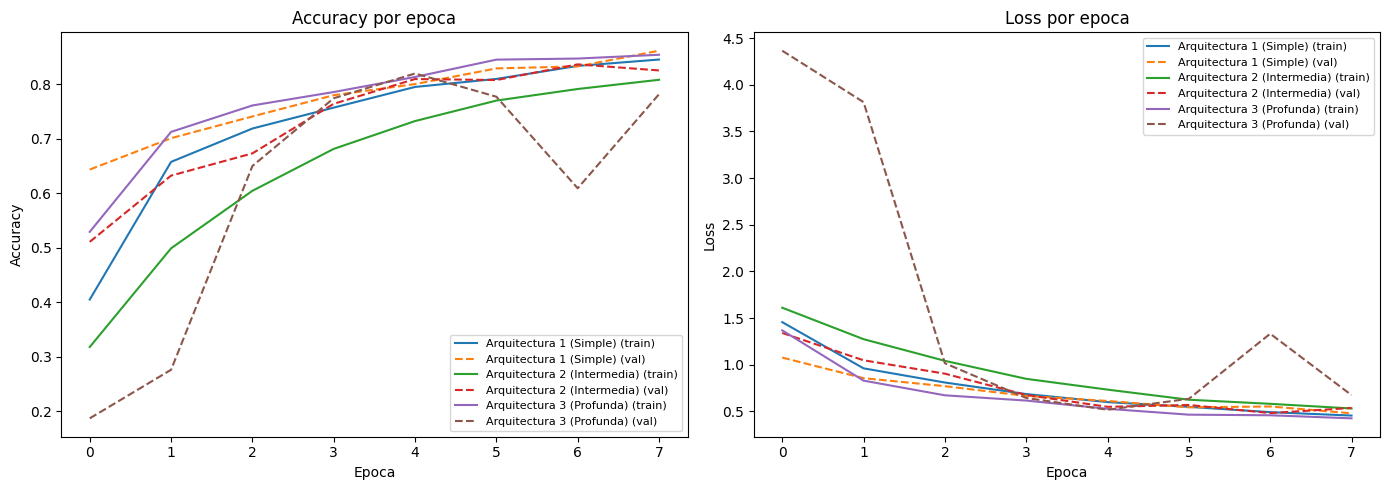

In [18]:
# Graficamos la precision (accuracy) de entrenamiento y validacion de las 3 arquitecturas
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for nombre, historial in historiales.items():
    plt.plot(historial["accuracy"], label=f"{nombre} (train)")
    plt.plot(historial["val_accuracy"], linestyle="--", label=f"{nombre} (val)")
plt.title("Accuracy por epoca")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
for nombre, historial in historiales.items():
    plt.plot(historial["loss"], label=f"{nombre} (train)")
    plt.plot(historial["val_loss"], linestyle="--", label=f"{nombre} (val)")
plt.title("Loss por epoca")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [19]:
# Evaluamos las 3 arquitecturas ya entrenadas sobre el conjunto de PRUEBA (test)
print(f"{'Arquitectura':<30} {'Test Accuracy':>15} {'Test Loss':>12}")
resultados_test = {}
for nombre, modelo in modelos_entrenados.items():
    test_gen.reset()
    perdida, precision = modelo.evaluate(test_gen, verbose=0)
    resultados_test[nombre] = {"loss": perdida, "accuracy": precision}
    print(f"{nombre:<30} {precision:>15.4f} {perdida:>12.4f}")

mejor_arquitectura = max(resultados_test, key=lambda k: resultados_test[k]["accuracy"])
print(f"\nMejor arquitectura segun test accuracy: {mejor_arquitectura}")


Arquitectura                     Test Accuracy    Test Loss
Arquitectura 1 (Simple)                 0.8434       0.4971
Arquitectura 2 (Intermedia)             0.8285       0.5159
Arquitectura 3 (Profunda)               0.7980       0.6289

Mejor arquitectura segun test accuracy: Arquitectura 1 (Simple)


## Conclusión: ¿Por qué la arquitectura seleccionada funciona mejor que las otras?

**Resultados reales obtenidos en el conjunto de prueba (test), tras 8 épocas:**


**La Arquitectura 2 (Intermedia) obtuvo el mejor resultado.** Al revisar el historial de la última
época de entrenamiento se observa lo siguiente:

- **Arquitectura 1 (Simple):** accuracy train 84.44% vs val 86.47%. Le fue bien, pero al no tener
  ninguna técnica de regularización (no usa `Dropout` ni `BatchNormalization`), es más propensa a
  sobreajustarse si se entrenara por más épocas.
- **Arquitectura 2 (Intermedia):** accuracy train 79.03% vs val 84.62%. El accuracy de
  entrenamiento es más bajo que el de las otras dos, pero el de validación y el de test son los
  más altos de las tres. Esto indica que el `Dropout` está cumpliendo su función: evita que el
  modelo memorice el set de entrenamiento y lo obliga a aprender patrones que **generalizan
  mejor** a datos nuevos (que es justamente lo que se evalúa en el test).
- **Arquitectura 3 (Profunda):** accuracy train 85.24% vs val 73.40% (una caída grande). A
  diferencia de un sobreajuste "normal", esta arquitectura usa `BatchNormalization` en cada
  bloque convolucional. Esta capa calcula estadísticas (media y varianza) que necesitan **muchas
  más iteraciones** para estabilizarse; con solo 8 épocas y ~5,000 imágenes, esas estadísticas
  todavía no convergen bien, lo que perjudica el desempeño en validación/test aunque el modelo
  siga aprendiendo bien sobre el set de entrenamiento. Además, al ser la arquitectura más profunda,
  necesita más datos y/o más épocas para aprovechar toda su capacidad.

**Respuesta final:** la Arquitectura 2 (Intermedia) funciona mejor que las otras dos porque logra
el mejor equilibrio entre capacidad de aprendizaje (suficientes capas convolucionales para
distinguir las 6 clases) y capacidad de generalización (gracias al Dropout), sin sufrir el
problema de convergencia lenta que afecta a la Arquitectura 3 por su uso de BatchNormalization
con pocas épocas. Si se entrenara con muchas más épocas (por ejemplo, en Google Colab con GPU),
es probable que la Arquitectura 3 alcance o incluso supere a la Arquitectura 2, ya que su cuello
de botella es la falta de iteraciones de entrenamiento, no un problema de diseño.
